# 🌍 Global Happiness Report Analysis

### Exploring happiness, social support, health, and economic factors across countries

**Python · Pandas · NumPy · Matplotlib · Seaborn**

---

> **Project Goal**  
> Analyze World Happiness Report data to understand patterns in country-level life evaluation and explore how happiness is associated with GDP per capita, social support, and healthy life expectancy.

**Notebook style:** Clean · Beginner-friendly · Reproducible · Presentation-ready


## 📌 1. Project Overview

Happiness varies across countries and can be explored through measurable indicators of wellbeing and living conditions.

In this notebook, the **Life evaluation (3-year average)** is used as the primary happiness measure. The analysis focuses on:

- Country-wise happiness rankings
- Top 10 and Bottom 10 countries
- Social support vs life evaluation
- Healthy life expectancy vs life evaluation
- Log GDP per capita vs life evaluation
- Correlation analysis
- Data-quality checks
- Clear, evidence-based observations

### Key principle

**Correlation indicates association, not causation.**

The analysis therefore describes relationships found in the dataset without claiming that a particular factor directly causes happiness.


## 🧭 2. Analysis Workflow

**Load → Inspect → Check Quality → Prepare → Analyze → Visualize → Interpret → Export**

The notebook is intentionally organized into small cells so that each important operation can be understood and executed independently.


In [25]:
# Core libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

DATA_PATH = Path("../data/Global_Happiness_Report.csv")
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 📂 3. Load the Dataset

The dataset is stored one level above this notebook inside the project's `data/` folder.

This relative path makes the notebook suitable for a GitHub repository with the following structure:

```text
Global-Happiness-Report-Analysis/
├── notebook/
│   └── Global_Happiness_Report_Analysis.ipynb
├── data/
│   └── Global_Happiness_Report.csv
├── output/
└── README.md
```


In [26]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 1,969 rows × 13 columns


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,147,Afghanistan,1.364,1.301,1.427,0.649,0.0,0.155,0.0,0.075,0.135,0.348
1,2023,143,Afghanistan,1.721,1.667,1.775,0.628,0.0,0.242,0.0,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,1.795,1.923,0.645,0.0,0.087,0.0,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,2.339,2.469,0.758,0.0,0.289,0.0,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,2.449,2.596,0.370,0.0,0.126,0.0,0.122,0.010,1.895


## 🔎 4. Explore the Dataset

First, inspect the columns, data types, years, and number of countries.


In [27]:
print("Column names:")
display(pd.DataFrame({"Column": df.columns}))


Column names:


,Column
0,Year
1,Rank
2,Country name
3,Life evaluation (3-year average)
4,Lower whisker
5,Upper whisker
6,Explained by: Log GDP per capita
7,Explained by: Social support
8,Explained by: Healthy life expectancy
9,Explained by: Freedom to make life choices


In [28]:
print("Data types:")
display(df.dtypes.to_frame("Data Type"))


Data types:


,Data Type
Year,int64
Rank,int64
Country name,str
Life evaluation (3-year average),float64
Lower whisker,float64
Upper whisker,float64
Explained by: Log GDP per capita,float64
Explained by: Social support,float64
Explained by: Healthy life expectancy,float64
Explained by: Freedom to make life choices,float64


In [29]:
print(f"Year range: {int(df['Year'].min())} – {int(df['Year'].max())}")
print(f"Number of unique countries: {df['Country name'].nunique():,}")
print(f"Total observations: {len(df):,}")


Year range: 2011 – 2024
Number of unique countries: 168
Total observations: 1,969


## 🧹 5. Data Quality Check

Before analysis, check for missing values and duplicate records.

Missing values are **not replaced with invented values**. Rows are excluded only from calculations that require the missing variable.


In [30]:
missing = df.isna().sum().sort_values(ascending=False)

print("Missing values by column:")
display(missing.to_frame("Missing Values"))


Missing values by column:


,Missing Values
Dystopia + residual,1101
Explained by: Healthy life expectancy,1099
Explained by: Freedom to make life choices,1098
Explained by: Perceptions of corruption,1098
Explained by: Log GDP per capita,1097
Explained by: Generosity,1097
Explained by: Social support,1097
Lower whisker,1094
Upper whisker,1094
Life evaluation (3-year average),0


In [31]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")


Duplicate rows: 0


## 🧪 6. Prepare Analysis Variables

The project uses the following variables:

- **Life evaluation (3-year average)** → primary happiness measure
- **Log GDP per capita** → economic factor
- **Social support** → social wellbeing factor
- **Healthy life expectancy** → health-related factor


In [32]:
happiness_col = "Life evaluation (3-year average)"

factor_cols = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy"
]

analysis_cols = ["Country name", "Year", happiness_col] + factor_cols

analysis_df = df[analysis_cols].copy()

print("Selected analysis columns:")
display(analysis_df.head())


Selected analysis columns:


,Country name,Year,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy
0,Afghanistan,2024,1.364,0.649,0.0,0.155
1,Afghanistan,2023,1.721,0.628,0.0,0.242
2,Afghanistan,2022,1.859,0.645,0.0,0.087
3,Afghanistan,2021,2.404,0.758,0.0,0.289
4,Afghanistan,2020,2.523,0.370,0.0,0.126


In [33]:
latest_year = analysis_df["Year"].max()
latest = analysis_df[analysis_df["Year"] == latest_year].copy()

print(f"Latest available year: {latest_year}")
print(f"Observations in latest year: {len(latest):,}")


Latest available year: 2024
Observations in latest year: 147


## 📊 7. Descriptive Statistics

A statistical summary provides a quick overview of the selected variables in the latest available year.


In [34]:
summary = latest[factor_cols + [happiness_col]].describe().T
display(summary.round(3))


,count,mean,std,min,25%,50%,75%,max
Explained by: Log GDP per capita,147.0,1.319,0.394,0.000,1.037,1.347,1.648,2.028
Explained by: Social support,147.0,1.333,0.350,0.000,1.131,1.438,1.594,1.840
Explained by: Healthy life expectancy,146.0,0.551,0.219,0.000,0.414,0.550,0.713,0.948
Life evaluation (3-year average),147.0,5.578,1.158,1.364,4.702,5.868,6.479,7.736


## 🏆 8. Top 10 Happiest Countries

The latest available year is used for the main country-ranking analysis.

A horizontal bar chart is used because country names are easier to read this way.


In [35]:
top10 = (
    latest[["Country name", happiness_col]]
    .dropna()
    .nlargest(10, happiness_col)
    .reset_index(drop=True)
)

display(top10.round(3))


,Country name,Life evaluation (3-year average)
0,Finland,7.736
1,Denmark,7.521
2,Iceland,7.515
3,Sweden,7.345
4,Netherlands,7.306
5,Costa Rica,7.274
6,Norway,7.262
7,Israel,7.234
8,Luxembourg,7.122
9,Mexico,6.979


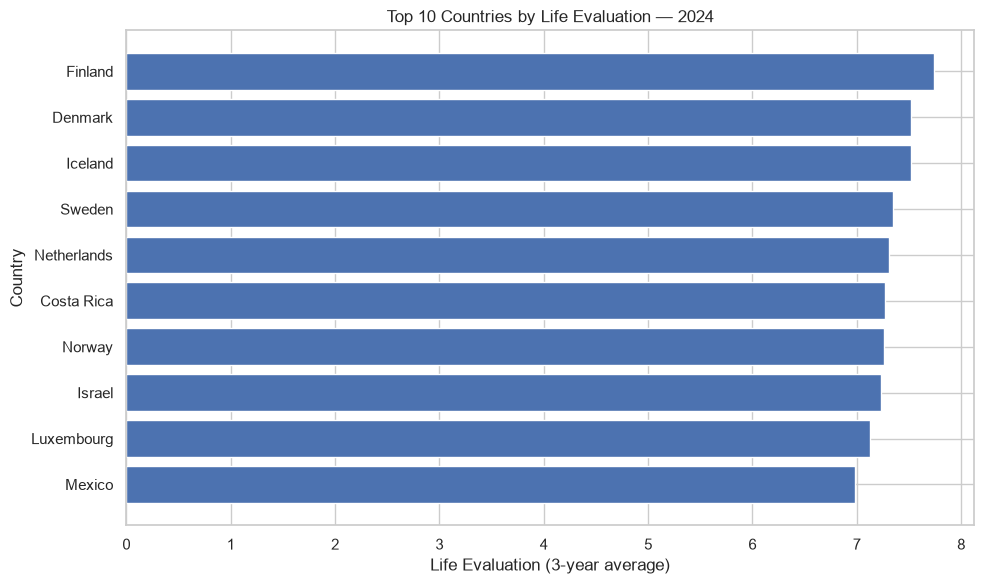

In [36]:
plt.figure(figsize=(10, 6))

plot_data = top10.sort_values(happiness_col)

plt.barh(plot_data["Country name"], plot_data[happiness_col])
plt.title(f"Top 10 Countries by Life Evaluation — {latest_year}")
plt.xlabel("Life Evaluation (3-year average)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 📉 9. Bottom 10 Countries by Happiness

The same happiness measure is used to identify countries at the lower end of the latest-year distribution.


In [37]:
bottom10 = (
    latest[["Country name", happiness_col]]
    .dropna()
    .nsmallest(10, happiness_col)
    .reset_index(drop=True)
)

display(bottom10.round(3))


,Country name,Life evaluation (3-year average)
0,Afghanistan,1.364
1,Sierra Leone,2.998
2,Lebanon,3.188
3,Malawi,3.260
4,Zimbabwe,3.396
5,Botswana,3.438
6,DR Congo,3.469
7,Yemen,3.561
8,Comoros,3.754
9,Lesotho,3.757


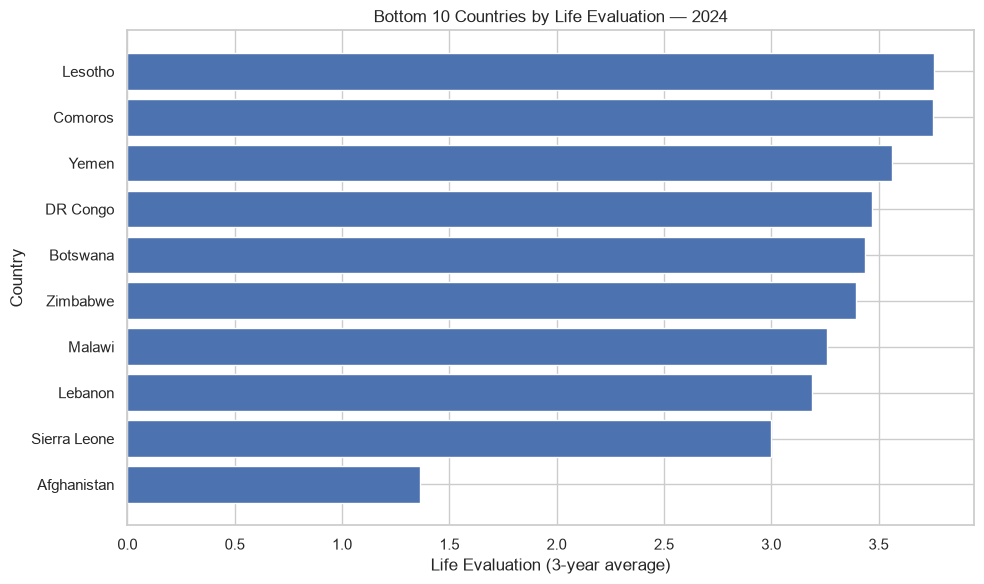

In [38]:
plt.figure(figsize=(10, 6))

plot_data = bottom10.sort_values(happiness_col)

plt.barh(plot_data["Country name"], plot_data[happiness_col])
plt.title(f"Bottom 10 Countries by Life Evaluation — {latest_year}")
plt.xlabel("Life Evaluation (3-year average)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 💰 GDP per Capita vs Happiness

Do countries with higher log GDP per capita tend to report higher life evaluation?


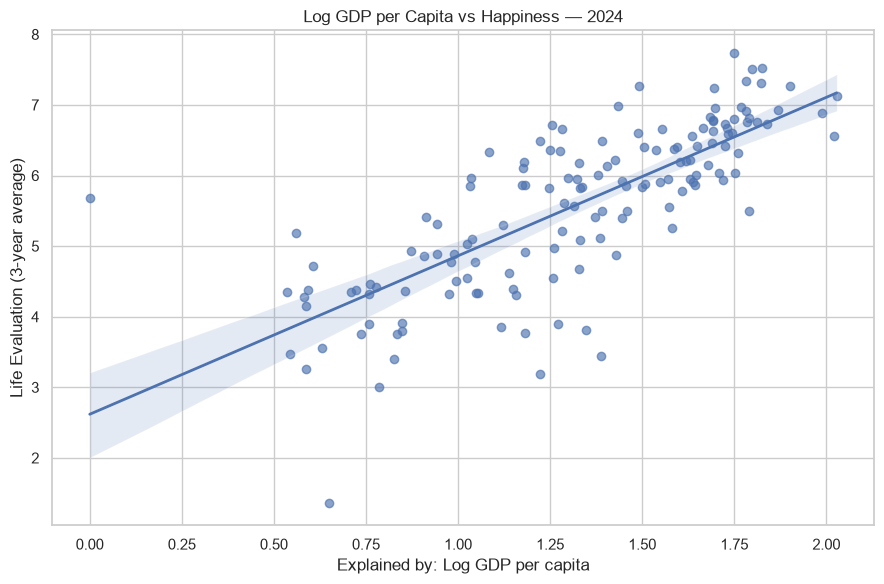

In [39]:
plt.figure(figsize=(9, 6))
sns.regplot(data=latest, x="Explained by: Log GDP per capita", y=happiness_col,
            scatter_kws={"alpha": 0.65}, line_kws={"linewidth": 2})
plt.title(f"Log GDP per Capita vs Happiness — {latest_year}")
plt.xlabel("Explained by: Log GDP per capita")
plt.ylabel("Life Evaluation (3-year average)")
plt.tight_layout()
plt.show()


## 🤝 10. Social Support vs Life Evaluation

This scatter plot explores whether higher social support tends to occur alongside higher life evaluation.

The regression line is used only as a visual guide to the overall linear pattern.


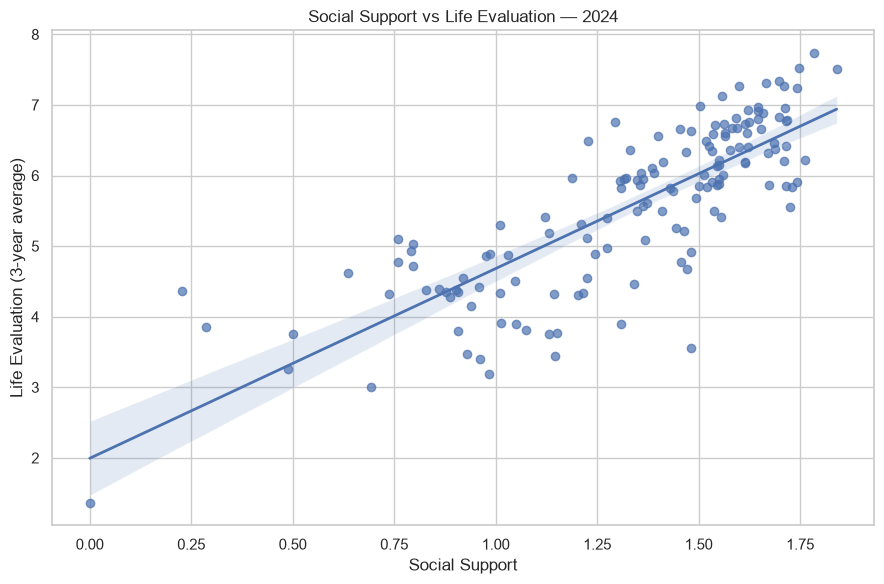

In [40]:
plot_df = latest.dropna(subset=["Explained by: Social support", happiness_col])

plt.figure(figsize=(9, 6))

sns.regplot(
    data=plot_df,
    x="Explained by: Social support",
    y=happiness_col,
    scatter_kws={"alpha": 0.70},
    line_kws={"linewidth": 2}
)

plt.title(f"Social Support vs Life Evaluation — {latest_year}")
plt.xlabel("Social Support")
plt.ylabel("Life Evaluation (3-year average)")
plt.tight_layout()
plt.show()


## 🎨 11. Enhanced Social Support Visualization

A second view uses point size to add another visual dimension while keeping the same two primary variables.

This helps make the country-level distribution easier to explore without changing the underlying data.


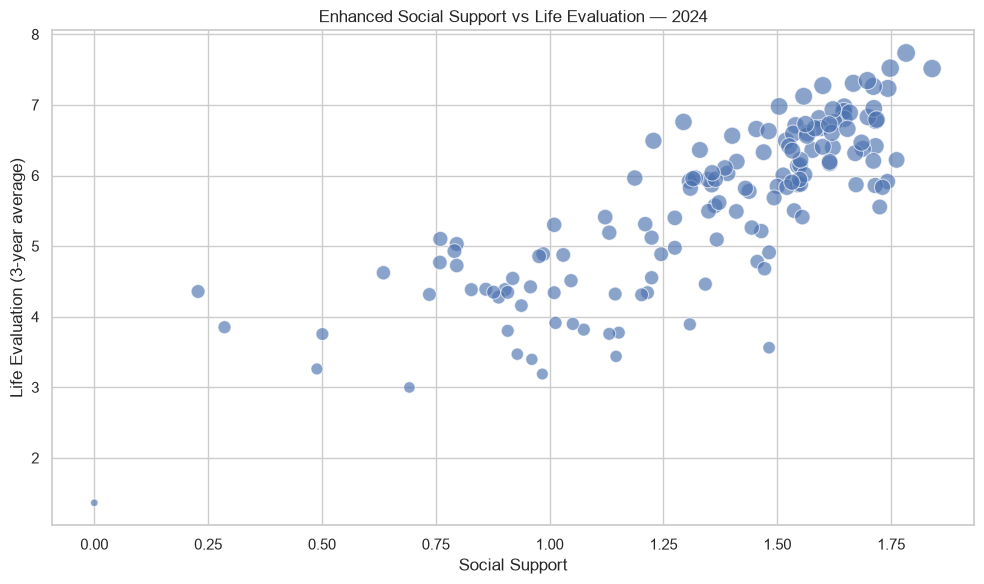

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="Explained by: Social support",
    y=happiness_col,
    size=happiness_col,
    sizes=(30, 180),
    alpha=0.65,
    legend=False
)

plt.title(f"Enhanced Social Support vs Life Evaluation — {latest_year}")
plt.xlabel("Social Support")
plt.ylabel("Life Evaluation (3-year average)")
plt.tight_layout()
plt.show()


## ❤️ 12. Healthy Life Expectancy vs Life Evaluation

Healthy life expectancy is compared with life evaluation to explore another wellbeing-related relationship.


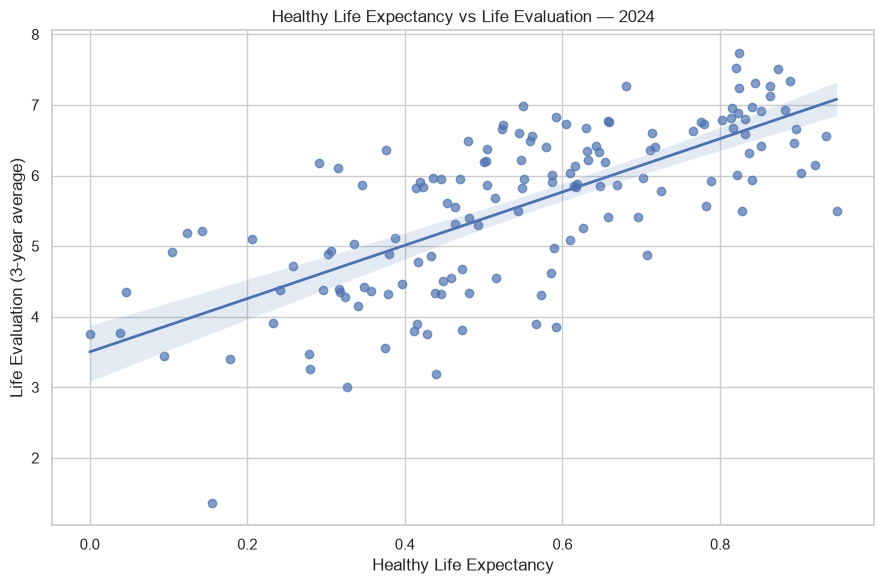

In [42]:
plot_df = latest.dropna(subset=["Explained by: Healthy life expectancy", happiness_col])

plt.figure(figsize=(9, 6))

sns.regplot(
    data=plot_df,
    x="Explained by: Healthy life expectancy",
    y=happiness_col,
    scatter_kws={"alpha": 0.70},
    line_kws={"linewidth": 2}
)

plt.title(f"Healthy Life Expectancy vs Life Evaluation — {latest_year}")
plt.xlabel("Healthy Life Expectancy")
plt.ylabel("Life Evaluation (3-year average)")
plt.tight_layout()
plt.show()


## 💰 13. Log GDP per Capita vs Life Evaluation

The dataset provides **Log GDP per capita**, so that exact variable is used for the economic comparison.

This chart helps examine whether countries with higher values of this measure also tend to report higher life evaluation.


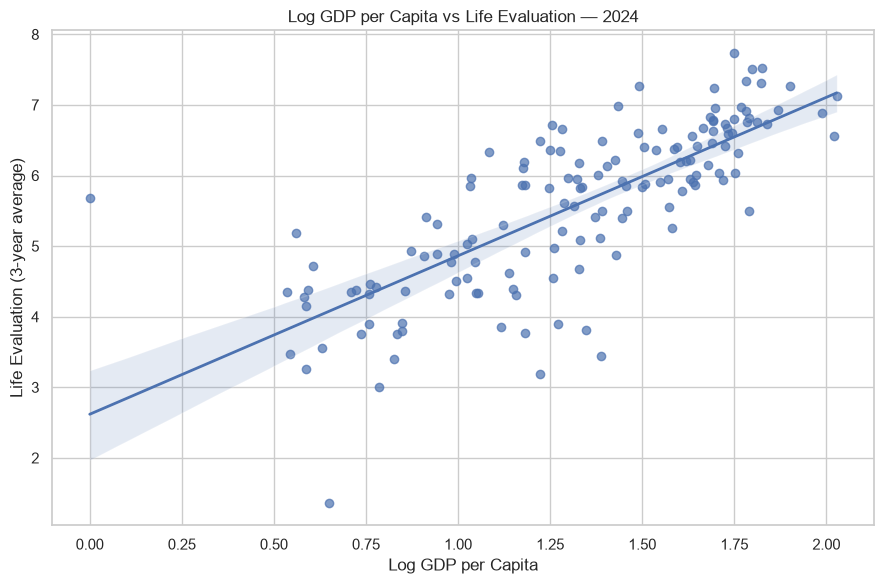

In [43]:
plot_df = latest.dropna(subset=["Explained by: Log GDP per capita", happiness_col])

plt.figure(figsize=(9, 6))

sns.regplot(
    data=plot_df,
    x="Explained by: Log GDP per capita",
    y=happiness_col,
    scatter_kws={"alpha": 0.70},
    line_kws={"linewidth": 2}
)

plt.title(f"Log GDP per Capita vs Life Evaluation — {latest_year}")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation (3-year average)")
plt.tight_layout()
plt.show()


## 🔗 14. Correlation Analysis

Correlation coefficients provide a numerical summary of the linear association between the selected variables.

- Values close to **+1** indicate a strong positive linear association.
- Values close to **−1** indicate a strong negative linear association.
- Values near **0** indicate a weak linear association.

These values should be interpreted together with the plots and dataset context.


In [44]:
corr_cols = factor_cols + [happiness_col]
corr_matrix = latest[corr_cols].corr()

display(corr_matrix.round(3))


,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Life evaluation (3-year average)
Explained by: Log GDP per capita,1.000,0.710,0.747,0.763
Explained by: Social support,0.710,1.000,0.595,0.812
Explained by: Healthy life expectancy,0.747,0.595,1.000,0.712
Life evaluation (3-year average),0.763,0.812,0.712,1.000


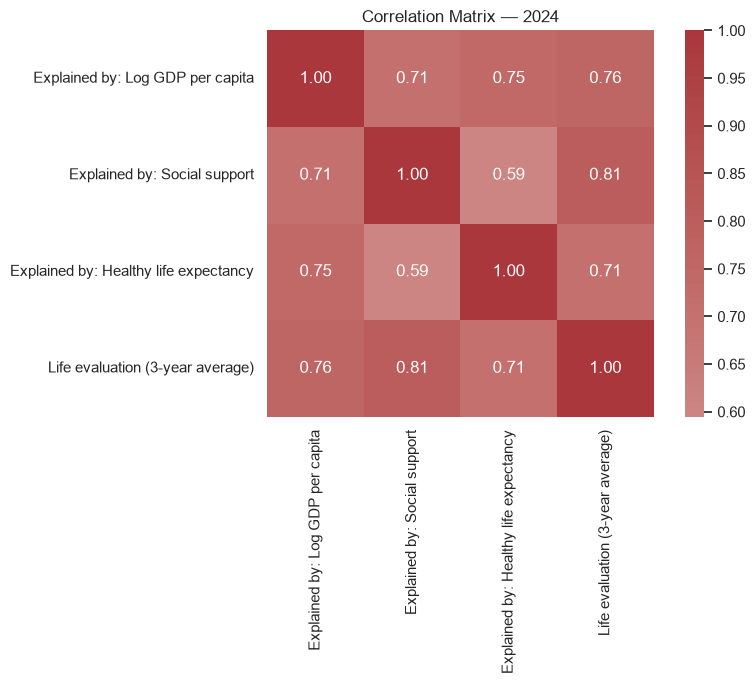

In [45]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True
)

plt.title(f"Correlation Matrix — {latest_year}")
plt.tight_layout()
plt.show()


## 📌 15. Correlation with Happiness

To focus specifically on the project question, list the correlation of each selected factor with life evaluation.


In [46]:
happiness_corr = (
    corr_matrix[happiness_col]
    .drop(happiness_col)
    .sort_values(ascending=False)
    .to_frame("Correlation with Life Evaluation")
)

display(happiness_corr.round(3))


,Correlation with Life Evaluation
Explained by: Social support,0.812
Explained by: Log GDP per capita,0.763
Explained by: Healthy life expectancy,0.712


## 💡 16. Evidence-Based Findings

The following values are generated directly from the latest-year calculations rather than being manually entered.

The wording intentionally avoids causal claims.


In [47]:
# Create compact, data-driven observations
top_country = top10.iloc[0]
bottom_country = bottom10.iloc[0]

strongest_factor = happiness_corr["Correlation with Life Evaluation"].abs().idxmax()
strongest_value = happiness_corr.loc[strongest_factor, "Correlation with Life Evaluation"]

print(f"• Highest life evaluation in the latest year: {top_country['Country name']} ({top_country[happiness_col]:.3f}).")
print(f"• Lowest life evaluation in the latest year among available observations: {bottom_country['Country name']} ({bottom_country[happiness_col]:.3f}).")
print(f"• Strongest absolute correlation with life evaluation among the selected factors: {strongest_factor} ({strongest_value:.3f}).")
print("• The scatter plots show the country-level distribution of the selected relationships.")
print("• Correlations describe association and should not be interpreted as proof of causation.")


• Highest life evaluation in the latest year: Finland (7.736).
• Lowest life evaluation in the latest year among available observations: Afghanistan (1.364).
• Strongest absolute correlation with life evaluation among the selected factors: Explained by: Social support (0.812).
• The scatter plots show the country-level distribution of the selected relationships.
• Correlations describe association and should not be interpreted as proof of causation.


## 📤 17. Export Important Results

Selected tables are exported so the analysis results remain available outside the notebook.


In [48]:
top10.to_csv(OUTPUT_DIR / "top_10_happiest_countries.csv", index=False)
bottom10.to_csv(OUTPUT_DIR / "bottom_10_countries.csv", index=False)
corr_matrix.to_csv(OUTPUT_DIR / "happiness_correlation_matrix.csv")

print("Export completed:")
print("✓ Top 10 countries")
print("✓ Bottom 10 countries")
print("✓ Correlation matrix")


Export completed:
✓ Top 10 countries
✓ Bottom 10 countries
✓ Correlation matrix


## ⚠️ 18. Assumptions & Limitations

### Assumptions
- The supplied Global Happiness Report CSV is treated as the source dataset.
- **Life evaluation (3-year average)** is used as the primary happiness measure.
- The latest available year is used for the main ranking visualizations.
- Missing values are not fabricated; calculations use available observations.
- Correlation is treated as an exploratory measure of association.

### Limitations
- Correlation does not imply causation.
- The dataset contains country-level observations and should not automatically be interpreted as individual-level behaviour.
- Life evaluation is a reported measure and does not represent every aspect of wellbeing.
- The main happiness measure is a 3-year average.
- The analysis focuses on selected explanatory factors available in the dataset.


## ✅ 19. Final Project Check

The requested analysis has been completed using a clear and reproducible workflow.


In [49]:
completion = pd.DataFrame({
    "Project Component": [
        "Dataset loading",
        "Data exploration",
        "Missing-value check",
        "Duplicate check",
        "Top 10 happiness analysis",
        "Bottom 10 happiness analysis",
        "Social support analysis",
        "Healthy life expectancy analysis",
        "GDP per capita analysis",
        "Correlation analysis",
        "Result export"
    ],
    "Status": ["Completed"] * 11
})

display(completion)
print("Project Status: Completed ✓")


,Project Component,Status
0,Dataset loading,Completed
1,Data exploration,Completed
2,Missing-value check,Completed
3,Duplicate check,Completed
4,Top 10 happiness analysis,Completed
5,Bottom 10 happiness analysis,Completed
6,Social support analysis,Completed
7,Healthy life expectancy analysis,Completed
8,GDP per capita analysis,Completed
9,Correlation analysis,Completed


Project Status: Completed ✓


---

## 🌍 Conclusion

This project demonstrates how Python can be used to explore a real-world Global Happiness Report dataset and turn country-level data into meaningful visual analysis.

The workflow covered:

**Data → Exploration → Data Quality → Analysis → Visualization → Findings → Export**

The main conclusion is intentionally cautious: the selected factors can be statistically associated with life evaluation, but the analysis alone cannot establish that they directly cause happiness.

---

### ⭐ Thank You

Thank you for taking the time to review this project.

Working on this analysis provided an opportunity to apply Python, Pandas, data visualization, and exploratory analysis to a real-world dataset.

I look forward to continuing to learn, build practical projects, and improve my ability to turn data into meaningful insights.
